***Filtrado por equipos, Selección de variables y Eliminación de nulos:***

In [2]:
import pandas as pd

# Cargamos todos los CSV filtrados
df_2021 = pd.read_csv('../data/filtered/LECdata-2021.csv', low_memory=False)
df_2022 = pd.read_csv('../data/filtered/LECdata-2022.csv', low_memory=False)
df_2023 = pd.read_csv('../data/filtered/LECdata-2023.csv', low_memory=False)
df_2024 = pd.read_csv('../data/filtered/LECdata-2024.csv', low_memory=False)
df_2025 = pd.read_csv('../data/filtered/LECdata-2025.csv', low_memory=False)

# Unificamos todos los datos en una variable
df_historico = pd.concat([df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True)


# ----------------- CÁLCULO DE WIN RATIO POR JUGADOR -----------------
# Tomamos las filas correspondientes a jugadores
df_jugadores = df_historico[df_historico['position'] != 'team'].copy()

# Realizamos una media de las victorias anteriores para cada jugador aplicando time decay (EWM)
df_jugadores['player_win_ratio'] = df_jugadores.groupby('playername')['result'].transform(lambda x: x.shift().ewm(span=20, min_periods=1).mean().round(4))
# Contamos la cantidad de partidas previas del jugador
df_jugadores['player_games'] = df_jugadores.groupby('playername')['result'].transform(lambda x: x.shift().expanding().count())

# Para los jugadores con menos de 20 partidas, el win ratio es 0.5 (50%)
df_jugadores['player_win_ratio'] = df_jugadores['player_win_ratio'].where(df_jugadores['player_games'] >= 20, 0.5).fillna(0.5)

# Asociamos el win ratio a cada posicón
df_wr = df_jugadores.pivot_table(index=['gameid', 'teamname'], columns='position', values='player_win_ratio').reset_index()
df_wr = df_wr.rename(columns={
    'top': 'wr_top',
    'jng': 'wr_jng',
    'mid': 'wr_mid',
    'bot': 'wr_bot',
    'sup': 'wr_sup'
})
# ---------------------------------------------------------------------------

# ----------------- MAPEO DE CAMPEONES POR POSICIÓN -----------------
# Asociamos el nombre del campeón a cada posición jugada
df_champs = df_jugadores.pivot(index=['gameid', 'teamname'], columns='position', values='champion').reset_index()
df_champs = df_champs.rename(columns={
    'top': 'champ_top',
    'jng': 'champ_jng',
    'mid': 'champ_mid',
    'bot': 'champ_bot',
    'sup': 'champ_sup'
})
# ---------------------------------------------------------------------------

# ----------------- CÁLCULO DE WIN RATIO POR CAMPEÓN -----------------
# Realizamos una media de las victorias anteriores para cada campeón aplicando time decay (EWM)
df_jugadores['champ_win_ratio'] = df_jugadores.groupby('champion')['result'].transform(lambda x: x.shift().ewm(span=20, min_periods=1).mean().round(4))
# Contamos la cantidad de partidas previas del campeón
df_jugadores['champ_wr_games'] = df_jugadores.groupby('champion')['result'].transform(lambda x: x.shift().expanding().count())

# Para los campeones con menos de 20 partidas, el win ratio es 0.5 (50%)
df_jugadores['champ_win_ratio'] = df_jugadores['champ_win_ratio'].where(df_jugadores['champ_wr_games'] >= 20, 0.5).fillna(0.5)

# Asociamos el win ratio del campeón a cada posición
df_champ_wr = df_jugadores.pivot_table(index=['gameid', 'teamname'], columns='position', values='champ_win_ratio').reset_index()
df_champ_wr = df_champ_wr.rename(columns={
    'top': 'wr_champ_top',
    'jng': 'wr_champ_jng',
    'mid': 'wr_champ_mid',
    'bot': 'wr_champ_bot',
    'sup': 'wr_champ_sup'
})
# ---------------------------------------------------------------------------

# ----------------- CÁLCULO DE COMP EARLY POWER POR EQUIPO -----------------
# Calculamos la media histórica de oro al min 15 para cada campeón aplicando time decay (EWM)
df_jugadores['champ_gold_mean'] = df_jugadores.groupby('champion')['golddiffat15'].transform(lambda x: x.shift().ewm(span=20, min_periods=1).mean().round(4))
# Contamos la cantidad de partidas previas del campeón
df_jugadores['champ_games'] = df_jugadores.groupby('champion')['golddiffat15'].transform(lambda x: x.shift().expanding().count())

# Si el campeón no tiene al menos 20 partidas previas, asignamos 0, si no, su media
df_jugadores['champ_early_power'] = df_jugadores['champ_gold_mean'].where(df_jugadores['champ_games'] >= 20, 0).fillna(0)

# Sumamos el valor de los 5 campeones por equipo
df_comp_early = df_jugadores.groupby(['gameid', 'teamname'])['champ_early_power'].sum().round(4).reset_index()
df_comp_early = df_comp_early.rename(columns={
    'champ_early_power': 'comp_early_power'
})
# ---------------------------------------------------------------------------


# Seleccionamos unicamente las filas resumen del equipo (team)
df_equipos = df_historico[df_historico['position'] == 'team'].copy()


# ----------------- CÁLCULO DE WIN RATIO POR EQUIPO (TEAM_WR) -----------------
# Unificamos MAD Lions KOI y Movistar KOI a KOI para calcular su winratio conjunto
teamnames_unificados = df_equipos['teamname'].replace({'MAD Lions KOI': 'KOI', 'Movistar KOI': 'KOI'})
df_equipos['team_wr'] = df_equipos.groupby(teamnames_unificados)['result'].transform(lambda x: x.shift().ewm(span=20, min_periods=1).mean().round(4))
df_equipos['team_games'] = df_equipos.groupby(teamnames_unificados)['result'].transform(lambda x: x.shift().expanding().count())

# Aplicamos el filtro de 20 partidas para los equipos también, asumiendo su wr en 0.5 si es más bajo
df_equipos['team_wr'] = df_equipos['team_wr'].where(df_equipos['team_games'] >= 20, 0.5).fillna(0.5)
# ---------------------------------------------------------------------------


# Unimos las columnas usando con el win ratio del jugador calculado
df_equipos = pd.merge(df_equipos, df_wr, on=['gameid', 'teamname'], how='left')

# Unimos con los campeones por posición
df_equipos = pd.merge(df_equipos, df_champs, on=['gameid', 'teamname'], how='left')

# Unimos con el win ratio del campeón calculado
df_equipos = pd.merge(df_equipos, df_champ_wr, on=['gameid', 'teamname'], how='left')

# Unimos también el comp_early_power calculado
df_equipos = pd.merge(df_equipos, df_comp_early, on=['gameid', 'teamname'], how='left')

#Seleccionamos las variables útiles para la predicción, sustituyendo los picks por posiciones
variables = ['playoffs', 'side', 'teamname', 'team_wr', 'champ_top', 'champ_jng', 'champ_mid', 'champ_bot', 'champ_sup', 
             'wr_champ_top', 'wr_champ_jng', 'wr_champ_mid', 'wr_champ_bot', 'wr_champ_sup',
             'firstdragon', 'golddiffat15', 'xpdiffat15', 'csdiffat15', 'killsat15', 'assistsat15', 'deathsat15',
             'wr_top', 'wr_jng', 'wr_mid', 'wr_bot', 'wr_sup', 'comp_early_power', 'result'
            ]

# Filtramos el DataFrame para quedarnos solo con las variables seleccionadas
df_equipos = df_equipos[variables]

# Renombramos MAD Lions KOI y Movistar KOI a KOI para unificar su nombre en el DataFrame final
df_equipos['teamname'] = df_equipos['teamname'].replace({'MAD Lions KOI': 'KOI', 'Movistar KOI': 'KOI'})


# Comprobamos que no haya valores nulos en el DataFrame y, si los hay, los eliminamos
if df_equipos.isnull().sum().sum() == 0:
    print("No hay valores nulos en el DataFrame.")
else:
    print("Hay valores nulos en el DataFrame. Se eliminarán las filas con valores nulos.")
    df_equipos = df_equipos.dropna()

# Guardamos el DataFrame filtrado en un nuevo CSV
df_equipos.to_csv('../data/teams/LEC-equipos.csv', index=False)

No hay valores nulos en el DataFrame.


***Prueba de Algoritmos:***

- Random Forest

Precisión del Random Forest: 0.6848



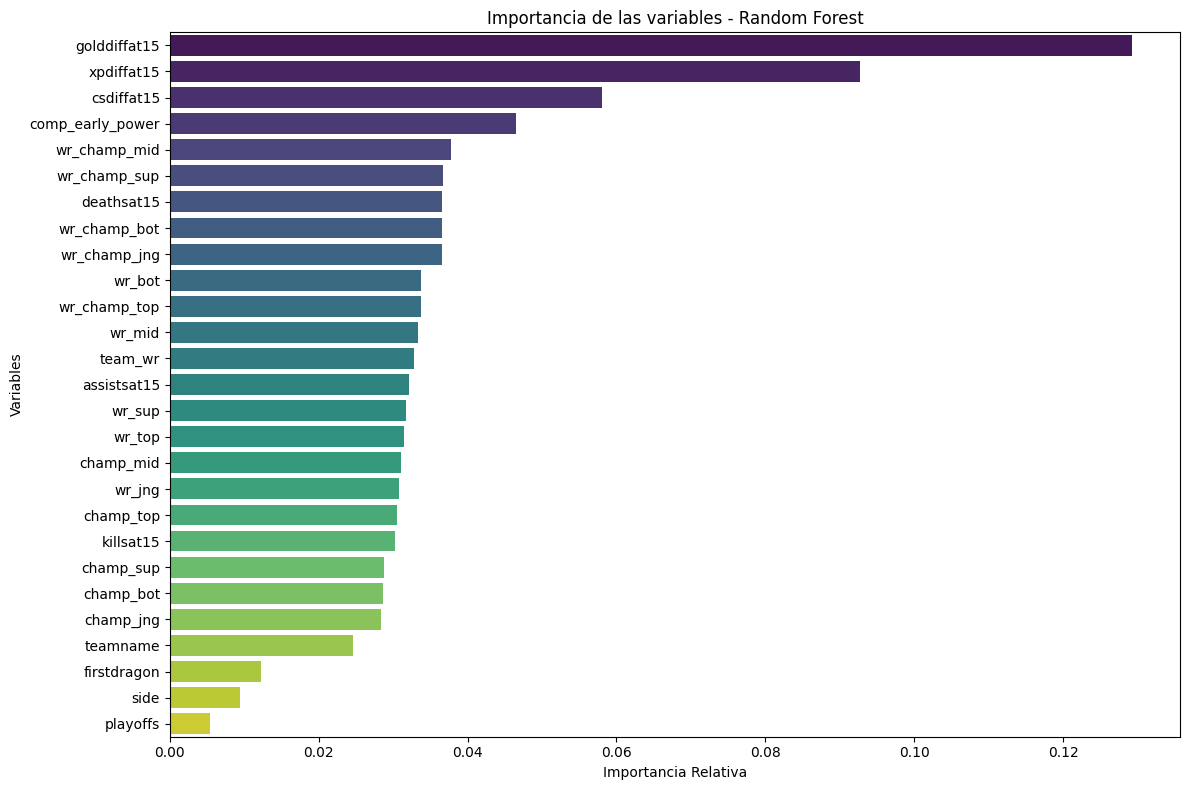

,Variable,Importancia
15,golddiffat15,0.129254
16,xpdiffat15,0.092760
17,csdiffat15,0.058079
26,comp_early_power,0.046505
11,wr_champ_mid,0.037803
13,wr_champ_sup,0.036766
20,deathsat15,0.036622
12,wr_champ_bot,0.036564
10,wr_champ_jng,0.036546
24,wr_bot,0.033807


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df_teams = pd.read_csv('../data/teams/LEC-equipos.csv')

# Separar variables predictoras (X) y la variable objetivo (y)
X = df_teams.drop('result', axis=1)
y = df_teams['result']

# Codificar las variables categóricas (como side, teamname, champs)
label_encoders = {}
# Actualizado para evitar el Pandas4Warning
categorical_cols = X.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    le = LabelEncoder()
    # Convertimos los valores a string por si hay algún dato mezclado y lo codificamos
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Dividimos los datos en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializamos el modelo Random Forest y lo entrenamos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Calculamos la precisión del modelo en el conjunto de prueba
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del Random Forest: {accuracy:.4f}\n")

# Extraemos la importancia de cada variable
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})

# Ordenamos por importancia de mayor a menor
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# ----------------- VISUALIZACIÓN -----------------
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=feature_importance_df, palette='viridis', legend=False)
plt.title('Importancia de las variables - Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Mostramos el ranking de las variables más importantes
feature_importance_df

- RandomForest Optimizado

Iniciando la búsqueda de hiperparámetros con GridSearchCV (esto puede tardar unos minutos)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejores parámetros encontrados:
 - max_depth: 6
 - min_samples_leaf: 2
 - min_samples_split: 25
 - n_estimators: 500

Precisión del Random Forest Optimizado: 0.7156



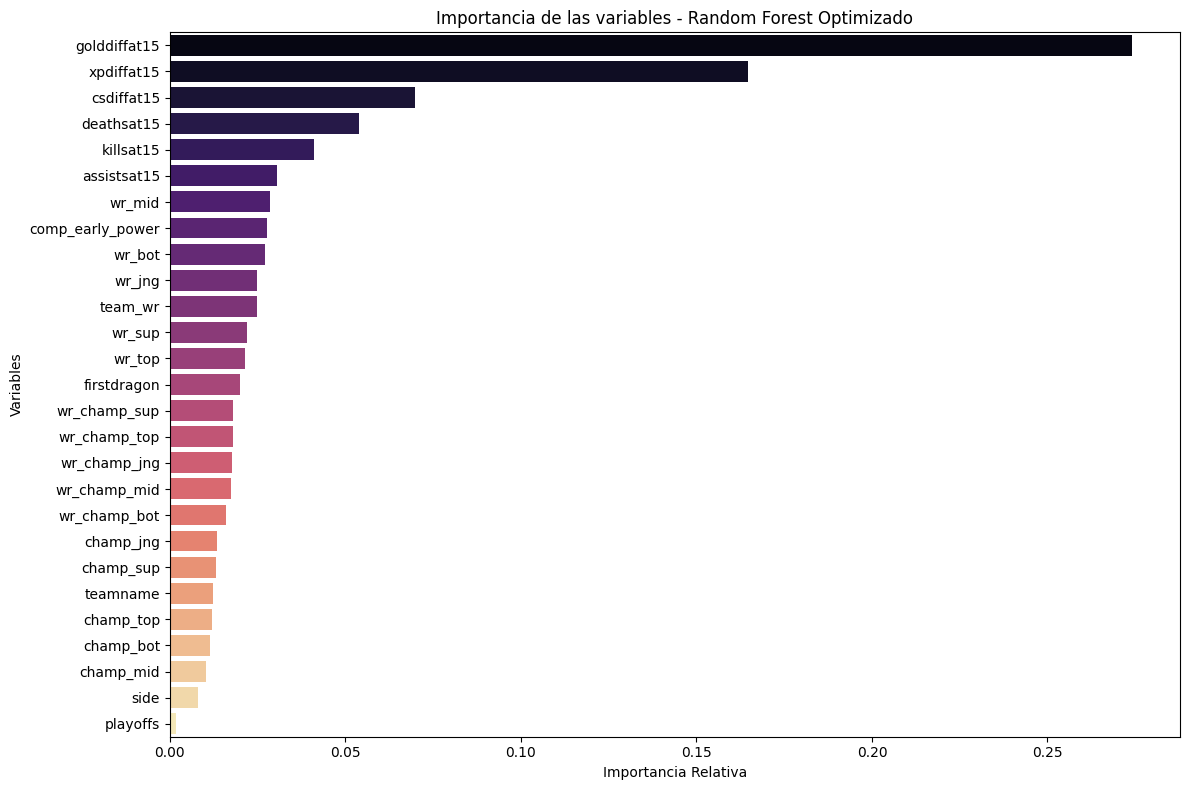

,Variable,Importancia
15,golddiffat15,0.274039
16,xpdiffat15,0.164560
17,csdiffat15,0.069826
20,deathsat15,0.053806
18,killsat15,0.041162
19,assistsat15,0.030538
23,wr_mid,0.028535
26,comp_early_power,0.027596
24,wr_bot,0.027121
22,wr_jng,0.024832


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos la cuadrícula (grid) de hiperparámetros a explorar
# Tras varias pruebas estos son los valores que parecen más prometedores para mejorar la precisión del modelo
param_grid = {
    'n_estimators': [450, 500, 550],         # Número de árboles
    'max_depth': [None, 4, 6, 8],           # Profundidad máxima del árbol
    'min_samples_split': [20, 25, 30],           # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 2, 3]              # Número mínimo de muestras requeridas para estar en un nodo hoja
}

# Inicializamos el modelo base
rf_base = RandomForestClassifier(random_state=42)

# Configuramos GridSearchCV 
# cv=5 hace validación cruzada con 5 pliegues
# n_jobs=-1 usa todos los núcleos del procesador disponibles para acelerar la búsqueda
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

print("Iniciando la búsqueda de hiperparámetros con GridSearchCV (esto puede tardar unos minutos)...")
# Entrenamos buscando los mejores parámetros (usa el mismo X_train, y_train definidos antes)
grid_search.fit(X_train, y_train)

# Mostramos los mejores parámetros encontrados
print(f"\nMejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

# Obtenemos el mejor modelo de la búsqueda
best_rf_model = grid_search.best_estimator_

# Calculamos la precisión con el mejor modelo en el conjunto de prueba
y_pred_opt = best_rf_model.predict(X_test)
accuracy_opt = accuracy_score(y_test, y_pred_opt)
print(f"\nPrecisión del Random Forest Optimizado: {accuracy_opt:.4f}\n")

# Extraemos la importancia de cada variable para el modelo optimizado
importances_opt = best_rf_model.feature_importances_
feature_importance_opt_df = pd.DataFrame({'Variable': X.columns, 'Importancia': importances_opt})
feature_importance_opt_df = feature_importance_opt_df.sort_values(by='Importancia', ascending=False)

# ----------------- VISUALIZACIÓN -----------------
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=feature_importance_opt_df, palette='magma', legend=False)
plt.title('Importancia de las variables - Random Forest Optimizado')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Mostramos el ranking de las variables más importantes
feature_importance_opt_df

- XGBoost

Precisión de XGBoost (sin optimizar): 0.6540



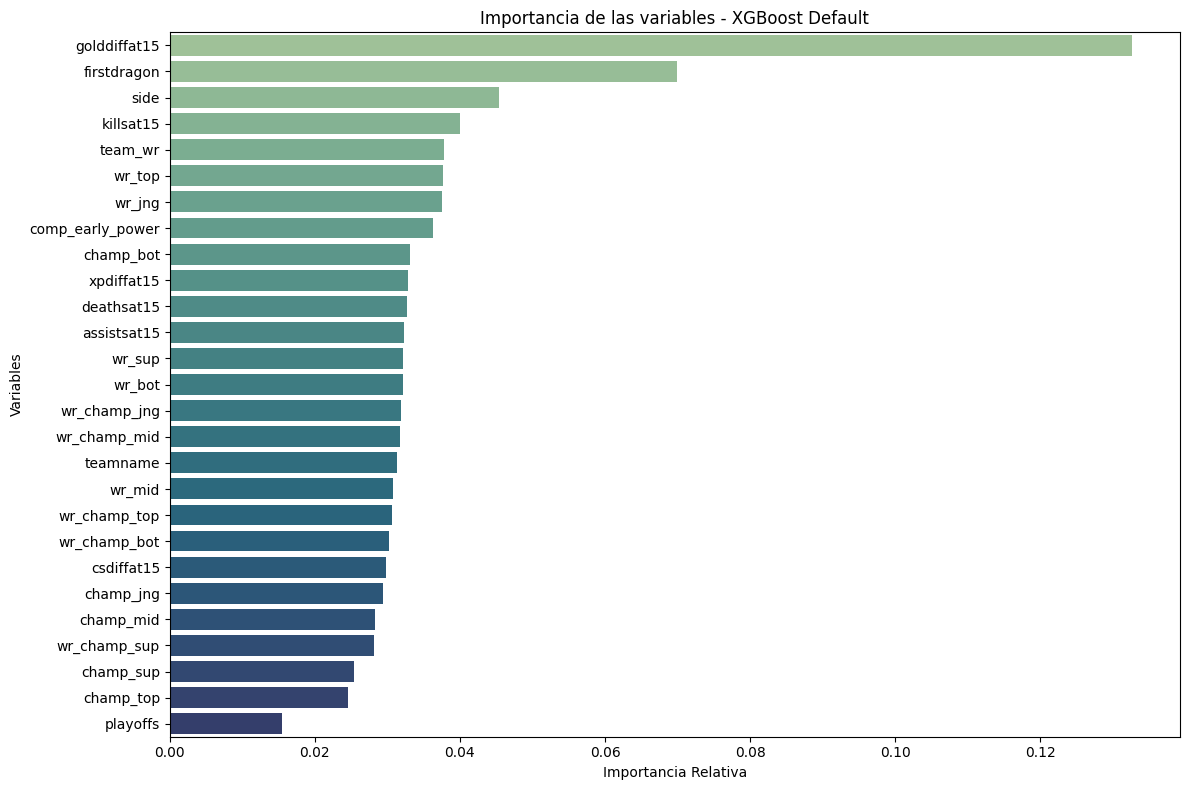

,Variable,Importancia
15,golddiffat15,0.132633
14,firstdragon,0.069861
1,side,0.045435
18,killsat15,0.039943
3,team_wr,0.037857
21,wr_top,0.037708
22,wr_jng,0.037522
26,comp_early_power,0.036262
7,champ_bot,0.033166
16,xpdiffat15,0.032774


In [ ]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Inicializamos el modelo XGBoost con los parámetros por defecto
# eval_metric='logloss' evita un warning común en versiones recientes
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# Entrenamos el modelo con los mismos datos de entrenamiento que usamos antes
xgb_model.fit(X_train, y_train)

# Calculamos la precisión del modelo en el conjunto de prueba
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Precisión de XGBoost (sin optimizar): {accuracy_xgb:.4f}\n")

# Extraemos la importancia de cada variable según XGBoost
importances_xgb = xgb_model.feature_importances_
feature_importance_xgb_df = pd.DataFrame({'Variable': X.columns, 'Importancia': importances_xgb})

# Ordenamos por importancia de mayor a menor
feature_importance_xgb_df = feature_importance_xgb_df.sort_values(by='Importancia', ascending=False)

# ----------------- VISUALIZACIÓN -----------------
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=feature_importance_xgb_df, palette='crest', legend=False)
plt.title('Importancia de las variables - XGBoost Default')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Mostramos el ranking de las variables más importantes
feature_importance_xgb_df

- XGBoost Optimizado

Iniciando la búsqueda de hiperparámetros de XGBoost con GridSearchCV (esto tardará un poco)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejores parámetros encontrados para XGBoost:
 - colsample_bytree: 1.0
 - learning_rate: 0.1
 - max_depth: 3
 - n_estimators: 50
 - subsample: 1.0

Precisión de XGBoost Optimizado: 0.7101



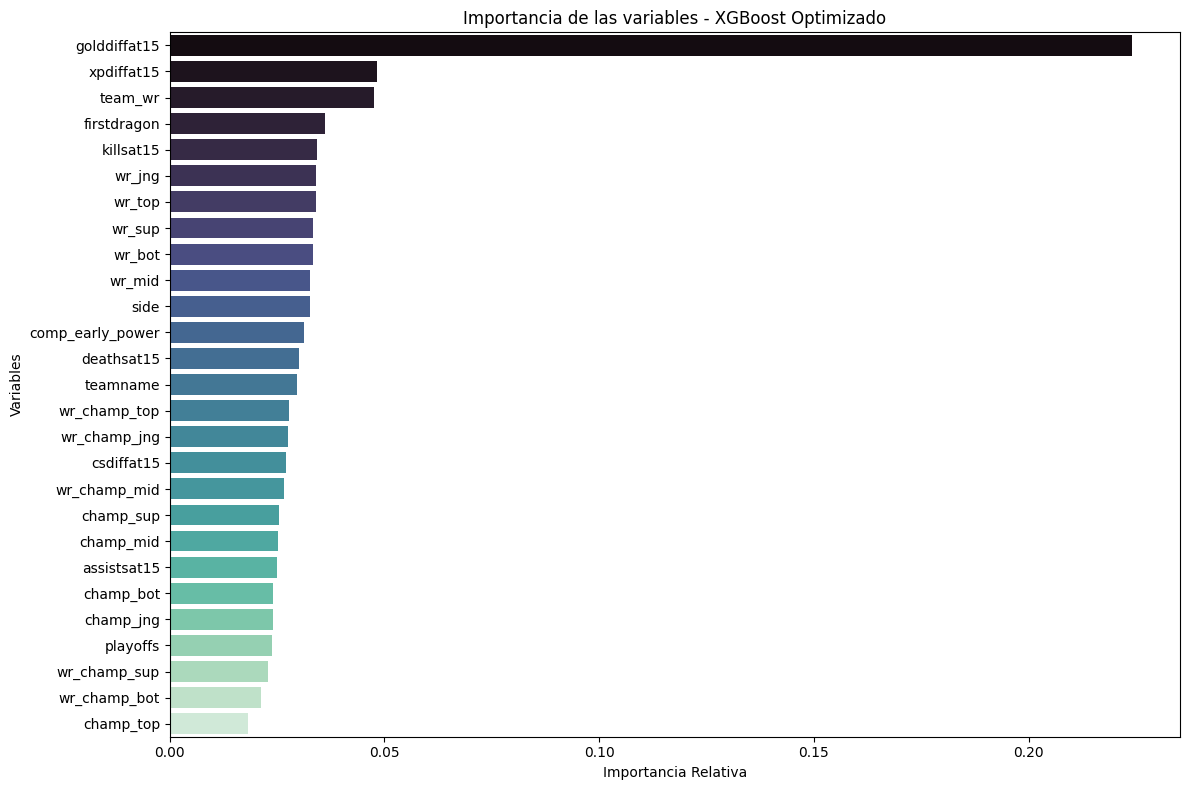

,Variable,Importancia
15,golddiffat15,0.224053
16,xpdiffat15,0.048201
3,team_wr,0.047445
14,firstdragon,0.036209
18,killsat15,0.034172
22,wr_jng,0.034158
21,wr_top,0.034014
25,wr_sup,0.033361
24,wr_bot,0.033252
23,wr_mid,0.032684


In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Definimos la cuadrícula (grid) de hiperparámetros a explorar para XGBoost
# Tras varias pruebas estos son los valores que parecen más prometedores para mejorar la precisión del modelo
param_grid_xgb = {
    'n_estimators': [50, 100, 150],            # Número de árboles
    'max_depth': [3, 5, 7],                     # Profundidad máxima del árbol (suele ser menor que en RF)
    'learning_rate': [0.01, 0.1, 0.2],          # Tasa de aprendizaje (qué tan rápido aprende)
    'subsample': [0.8, 1.0],                    # Fracción de muestras usadas para cada árbol
    'colsample_bytree': [0.8, 1.0]              # Fracción de columnas usadas para cada árbol
}

# Inicializamos el modelo base
xgb_base = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# Configuramos GridSearchCV 
grid_search_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, 
                               cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

print("Iniciando la búsqueda de hiperparámetros de XGBoost con GridSearchCV (esto tardará un poco)...")
# Entrenamos buscando los mejores parámetros
grid_search_xgb.fit(X_train, y_train)

# Mostramos los mejores parámetros encontrados
print(f"\nMejores parámetros encontrados para XGBoost:")
for param, value in grid_search_xgb.best_params_.items():
    print(f" - {param}: {value}")

# Obtenemos el mejor modelo de la búsqueda
best_xgb_model = grid_search_xgb.best_estimator_

# Calculamos la precisión con el mejor modelo en el conjunto de prueba
y_pred_opt_xgb = best_xgb_model.predict(X_test)
accuracy_opt_xgb = accuracy_score(y_test, y_pred_opt_xgb)
print(f"\nPrecisión de XGBoost Optimizado: {accuracy_opt_xgb:.4f}\n")

# Extraemos la importancia de cada variable para el modelo optimizado
importances_opt_xgb = best_xgb_model.feature_importances_
feature_importance_opt_xgb_df = pd.DataFrame({'Variable': X.columns, 'Importancia': importances_opt_xgb})
feature_importance_opt_xgb_df = feature_importance_opt_xgb_df.sort_values(by='Importancia', ascending=False)

# ----------------- VISUALIZACIÓN -----------------
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=feature_importance_opt_xgb_df, palette='mako', legend=False)
plt.title('Importancia de las variables - XGBoost Optimizado')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Mostramos el ranking de las variables más importantes
feature_importance_opt_xgb_df

- Regresión Logística

Precisión de la Regresión Logística: 0.7210



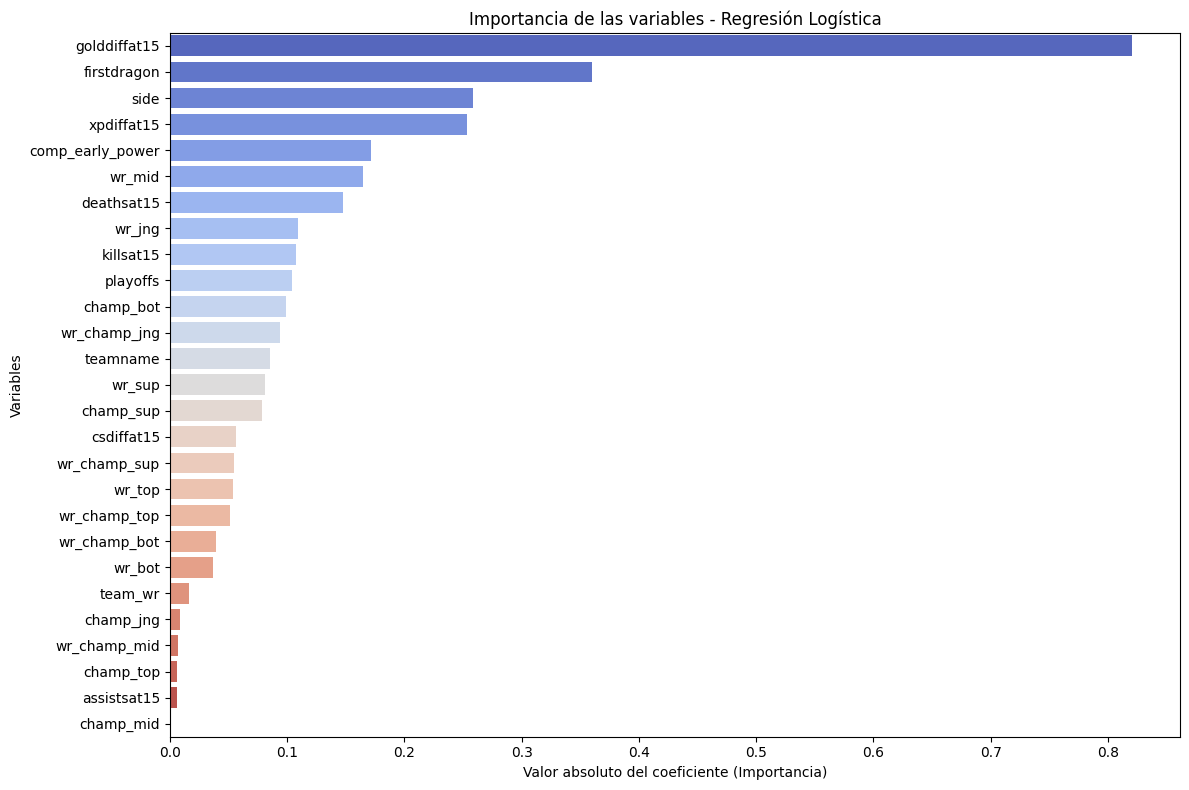

,Variable,Importancia
15,golddiffat15,0.820335
14,firstdragon,0.360218
1,side,0.258842
16,xpdiffat15,0.253659
26,comp_early_power,0.171201
23,wr_mid,0.164734
20,deathsat15,0.148110
22,wr_jng,0.108969
18,killsat15,0.107749
0,playoffs,0.104223


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Necesitamos estandarizar/normalizar los datos antes de entrenar.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicializamos el modelo de Regresión Logística
# max_iter=1000 asegura que el algoritmo tenga suficientes iteraciones para converger
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

# Entrenamos el modelo con los datos escalados
log_reg_model.fit(X_train_scaled, y_train)

# Calculamos la precisión en el conjunto de prueba
y_pred_lr = log_reg_model.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Precisión de la Regresión Logística: {accuracy_lr:.4f}\n")

# Extraemos la importancia estudiando el valor absoluto de los coeficientes de las variables.
importances_lr = np.abs(log_reg_model.coef_[0])
feature_importance_lr_df = pd.DataFrame({'Variable': X.columns, 'Importancia': importances_lr})

# Ordenamos por importancia de mayor a menor
feature_importance_lr_df = feature_importance_lr_df.sort_values(by='Importancia', ascending=False)

# ----------------- VISUALIZACIÓN -----------------
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=feature_importance_lr_df, palette='coolwarm', legend=False)
plt.title('Importancia de las variables - Regresión Logística')
plt.xlabel('Valor absoluto del coeficiente (Importancia)')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Mostramos el ranking de las variables más importantes
feature_importance_lr_df

- Regresión Logística Optimizada

Iniciando la búsqueda de hiperparámetros de Regresión Logística (usando datos escalados)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Mejores parámetros encontrados para Regresión Logística:
 - C: 0.01
 - class_weight: None
 - l1_ratio: 0

Precisión de Regresión Logística Optimizada: 0.7192



Iniciando la búsqueda de hiperparámetros de Regresión Logística (usando datos escalados)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Mejores parámetros encontrados para Regresión Logística:
 - C: 0.01
 - class_weight: None
 - l1_ratio: 0

Precisión de Regresión Logística Optimizada: 0.7192



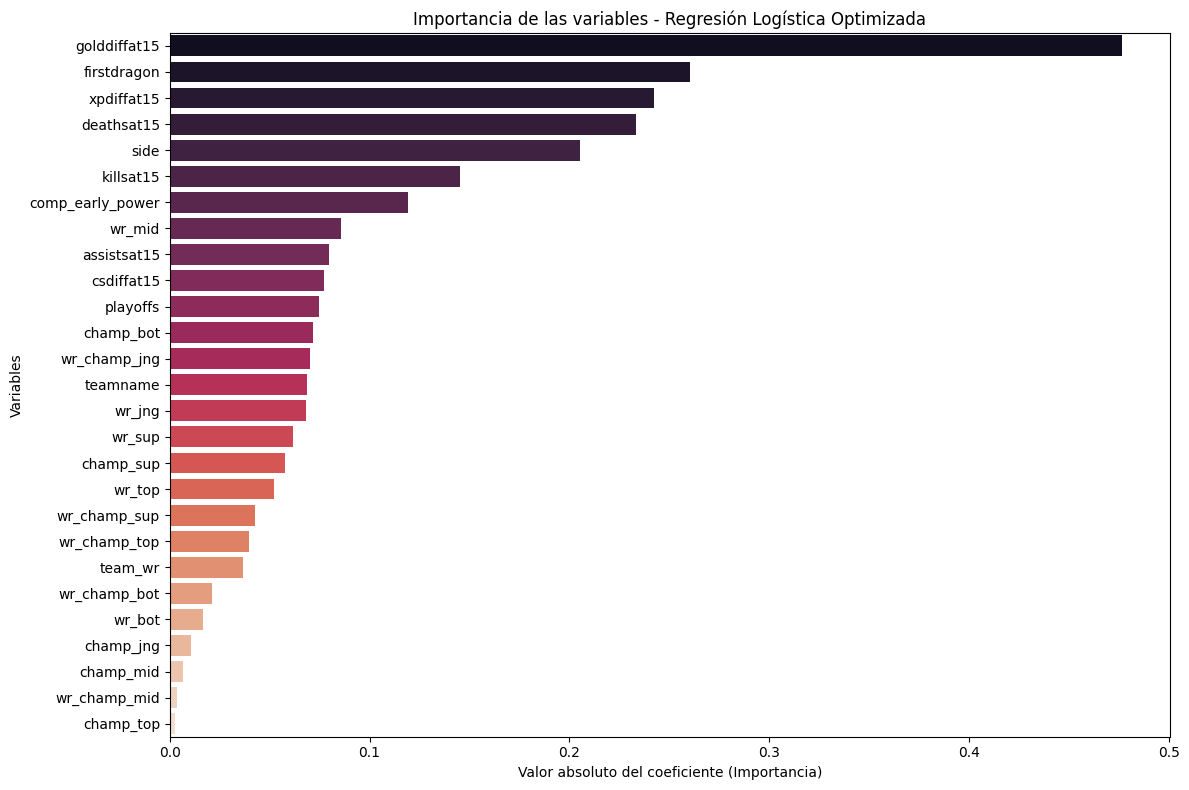

,Variable,Importancia
15,golddiffat15,0.476648
14,firstdragon,0.260404
16,xpdiffat15,0.242096
20,deathsat15,0.233507
1,side,0.205309
18,killsat15,0.145347
26,comp_early_power,0.119296
23,wr_mid,0.085551
19,assistsat15,0.079462
17,csdiffat15,0.077023


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos la cuadrícula (grid) de hiperparámetros a explorar para Regresión Logística
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],      # Inverso de la fuerza de regularización (menor valor = más regularización)
    'penalty': ['l1', 'l2'],                  # Tipo de penalización (Lasso 'l1' o Ridge 'l2')
    'solver': ['liblinear', 'saga']           # Algoritmos de optimización que soportan tanto L1 como L2
}

# Inicializamos el modelo base
# Aumentamos max_iter porque algunos solvers (como 'saga') pueden necesitar más iteraciones para converger
lr_base = LogisticRegression(random_state=42, max_iter=2000)

# Configuramos GridSearchCV 
grid_search_lr = GridSearchCV(estimator=lr_base, param_grid=param_grid_lr, 
                               cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

print("Iniciando la búsqueda de hiperparámetros de Regresión Logística (usando datos escalados)...")
# Entrenamos buscando los mejores parámetros usando los datos escalados
grid_search_lr.fit(X_train_scaled, y_train)

# Mostramos los mejores parámetros encontrados
print(f"\nMejores parámetros encontrados para Regresión Logística:")
for param, value in grid_search_lr.best_params_.items():
    print(f" - {param}: {value}")

# Obtenemos el mejor modelo de la búsqueda
best_lr_model = grid_search_lr.best_estimator_

# Calculamos la precisión con el mejor modelo en el conjunto de prueba
y_pred_opt_lr = best_lr_model.predict(X_test_scaled)
accuracy_opt_lr = accuracy_score(y_test, y_pred_opt_lr)
print(f"\nPrecisión de Regresión Logística Optimizada: {accuracy_opt_lr:.4f}\n")

# Extraemos la importancia de cada variable para el modelo optimizado
importances_opt_lr = np.abs(best_lr_model.coef_[0])
feature_importance_opt_lr_df = pd.DataFrame({'Variable': X.columns, 'Importancia': importances_opt_lr})
feature_importance_opt_lr_df = feature_importance_opt_lr_df.sort_values(by='Importancia', ascending=False)

# ----------------- VISUALIZACIÓN -----------------
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=feature_importance_opt_lr_df, palette='rocket', legend=False)
plt.title('Importancia de las variables - Regresión Logística Optimizada')
plt.xlabel('Valor absoluto del coeficiente (Importancia)')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Mostramos el ranking de las variables más importantes
feature_importance_opt_lr_df